In [708]:
import pandas as pd  ## data handling i.e reading the data
import numpy as np
import seaborn as sns ##'''visualizing the dataset'''
import matplotlib.pyplot as plt                            
from sklearn.model_selection import train_test_split, cross_val_score   ## training and testing models
from sklearn.preprocessing import StandardScaler, MinMaxScaler   ## normalizing and standardizing the datatset 
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.linear_model import Lasso, Ridge
from sklearn.linear_model import ElasticNet# # suitable regression models for the dataset
from sklearn.metrics import r2_score,mean_squared_error
import warnings
warnings.filterwarnings("ignore")


In [709]:
nas= pd.read_csv("NYhousing.csv")

In [710]:
nas.head()

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.000000,1400.0,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483
1,Brokered by Serhant,Condo for sale,195000000,7,10.000000,17545.0,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991
2,Brokered by Sowae Corp,House for sale,260000,4,2.000000,2015.0,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109
3,Brokered by COMPASS,Condo for sale,69000,3,1.000000,445.0,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.373861,14175.0,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856


In [711]:
nas.shape

(4801, 17)

In [712]:
nas.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4801 entries, 0 to 4800
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  4801 non-null   object 
 1   TYPE                         4801 non-null   object 
 2   PRICE                        4801 non-null   int64  
 3   BEDS                         4801 non-null   int64  
 4   BATH                         4801 non-null   float64
 5   PROPERTYSQFT                 4801 non-null   float64
 6   ADDRESS                      4801 non-null   object 
 7   STATE                        4801 non-null   object 
 8   MAIN_ADDRESS                 4801 non-null   object 
 9   ADMINISTRATIVE_AREA_LEVEL_2  4801 non-null   object 
 10  LOCALITY                     4801 non-null   object 
 11  SUBLOCALITY                  4801 non-null   object 
 12  STREET_NAME                  4801 non-null   object 
 13  LONG_NAME         

In [713]:
nas.describe()

,PRICE,BEDS,BATH,PROPERTYSQFT,LATITUDE,LONGITUDE
count,4.801000e+03,4801.000000,4801.000000,4801.000000,4801.000000,4801.000000
mean,2.356940e+06,3.356801,2.373861,2184.207862,40.714227,-73.941601
std,3.135525e+07,2.602315,1.946962,2377.140894,0.087676,0.101082
min,2.494000e+03,1.000000,0.000000,230.000000,40.499546,-74.253033
25%,4.990000e+05,2.000000,1.000000,1200.000000,40.639375,-73.987143
50%,8.250000e+05,3.000000,2.000000,2184.207862,40.726749,-73.949189
75%,1.495000e+06,4.000000,3.000000,2184.207862,40.771923,-73.870638
max,2.147484e+09,50.000000,50.000000,65535.000000,40.912729,-73.702450


In [714]:
nas.duplicated().sum()

np.int64(214)

In [715]:
nas

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.000000,1400.000000,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483
1,Brokered by Serhant,Condo for sale,195000000,7,10.000000,17545.000000,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991
2,Brokered by Sowae Corp,House for sale,260000,4,2.000000,2015.000000,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109
3,Brokered by COMPASS,Condo for sale,69000,3,1.000000,445.000000,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.373861,14175.000000,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4796,Brokered by COMPASS,Co-op for sale,599000,1,1.000000,2184.207862,222 E 80th St Apt 3A,"Manhattan, NY 10075","222 E 80th St Apt 3AManhattan, NY 10075",New York,New York County,New York,Manhattan,222,"222 E 80th St #3a, New York, NY 10075, USA",40.774350,-73.955879
4797,Brokered by Mjr Real Estate Llc,Co-op for sale,245000,1,1.000000,2184.207862,97-40 62 Dr Unit Lg,"Rego Park, NY 11374","97-40 62 Dr Unit LgRego Park, NY 11374",United States,New York,Queens County,Queens,62nd Drive,"97-40 62nd Dr, Rego Park, NY 11374, USA",40.732538,-73.860152
4798,Brokered by Douglas Elliman - 575 Madison Ave,Co-op for sale,1275000,1,1.000000,2184.207862,427 W 21st St Unit Garden,"New York, NY 10011","427 W 21st St Unit GardenNew York, NY 10011",United States,New York,New York County,New York,West 21st Street,"427 W 21st St, New York, NY 10011, USA",40.745882,-74.003398
4799,Brokered by E Realty International Corp,Condo for sale,598125,2,1.000000,655.000000,91-23 Corona Ave Unit 4G,"Elmhurst, NY 11373","91-23 Corona Ave Unit 4GElmhurst, NY 11373",New York,Queens County,Queens,Flushing,91-23,"91-23 Corona Ave. #4b, Flushing, NY 11373, USA",40.742770,-73.872752


In [716]:
nas[nas.duplicated(keep=False)] ## showing the actual duplicates.

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
80,Brokered by Douglas Elliman - 575 Madison Ave,Condo for sale,1650000,2,2.000000,1065.000000,200 E 94th St Apt 414,"New York, NY 10128","200 E 94th St Apt 414New York, NY 10128",New York,New York County,New York,Manhattan,200,"200 E 94th St APT 414, New York, NY 10128, USA",40.783355,-73.949998
81,Brokered by Douglas Elliman - 575 Madison Ave,Condo for sale,1650000,2,2.000000,1065.000000,200 E 94th St Apt 414,"New York, NY 10128","200 E 94th St Apt 414New York, NY 10128",New York,New York County,New York,Manhattan,200,"200 E 94th St APT 414, New York, NY 10128, USA",40.783355,-73.949998
113,Brokered by Sowae Corp,House for sale,400000,4,2.000000,1980.000000,781 Sheperd Ave,"Brooklyn, NY 11208","781 Sheperd AveBrooklyn, NY 11208",United States,New York,Kings County,Brooklyn,Shepherd Avenue,"781 Shepherd Ave, Brooklyn, NY 11208, USA",40.665357,-73.877087
114,Brokered by Sowae Corp,Multi-family home for sale,346000,5,2.000000,2184.207862,103-12 104th St,"Ozone Park, NY 11417","103-12 104th StOzone Park, NY 11417",United States,New York,Queens County,Queens,104th Street,"103-12 104th St, Jamaica, NY 11417, USA",40.683789,-73.838104
115,Brokered by Sowae Corp,House for sale,400000,4,2.000000,1980.000000,781 Sheperd Ave,"Brooklyn, NY 11208","781 Sheperd AveBrooklyn, NY 11208",United States,New York,Kings County,Brooklyn,Shepherd Avenue,"781 Shepherd Ave, Brooklyn, NY 11208, USA",40.665357,-73.877087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4760,NoBroker,Multi-family home for sale,2000000,8,2.373861,2184.207862,2324 60th St,"Brooklyn, NY 11204","2324 60th StBrooklyn, NY 11204",United States,New York,Kings County,Brooklyn,60th Street,"2324 60th St, Brooklyn, NY 11204, USA",40.614758,-73.975714
4770,Brokered by Sotheby's International Realty - E...,Condo for sale,2600000,3,2.000000,1729.000000,242 E 15th St Apt 1,"New York, NY 10003","242 E 15th St Apt 1New York, NY 10003",New York,New York County,New York,Manhattan,242,"242 E 15th St APT 1, New York, NY 10003, USA",40.733031,-73.985037
4775,Brokered by EXIT REALTY PREMIER,House for sale,749000,3,2.373861,2002.000000,631 Essex St,"Brooklyn, NY 11208","631 Essex StBrooklyn, NY 11208",United States,New York,Kings County,Brooklyn,Essex Street,"631 Essex St, Brooklyn, NY 11208, USA",40.668173,-73.880027
4780,NoBroker,Multi-family home for sale,2000000,8,2.373861,2184.207862,2324 60th St,"Brooklyn, NY 11204","2324 60th StBrooklyn, NY 11204",United States,New York,Kings County,Brooklyn,60th Street,"2324 60th St, Brooklyn, NY 11204, USA",40.614758,-73.975714


In [717]:
nas.drop_duplicates(inplace= True)

In [718]:
nas.shape

(4587, 17)

In [719]:
nas.isnull().sum()


BROKERTITLE                    0
TYPE                           0
PRICE                          0
BEDS                           0
BATH                           0
PROPERTYSQFT                   0
ADDRESS                        0
STATE                          0
MAIN_ADDRESS                   0
ADMINISTRATIVE_AREA_LEVEL_2    0
LOCALITY                       0
SUBLOCALITY                    0
STREET_NAME                    0
LONG_NAME                      0
FORMATTED_ADDRESS              0
LATITUDE                       0
LONGITUDE                      0
dtype: int64

In [720]:
nas.isnull()

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4796,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4797,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4798,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4799,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


Text(0.5, 1.0, 'HEATMAP FOR NUMERIC COLUMNS')

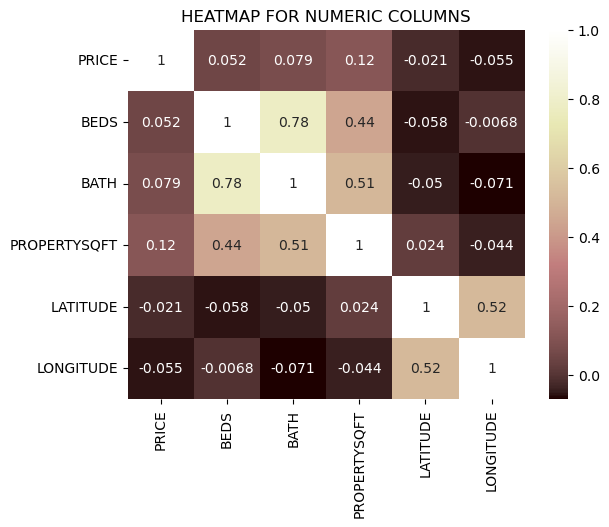

In [721]:
corr= nas.corr(numeric_only= True)
sns.heatmap(corr,
            annot=True,
            cmap="pink")
plt.title("HEATMAP FOR NUMERIC COLUMNS")

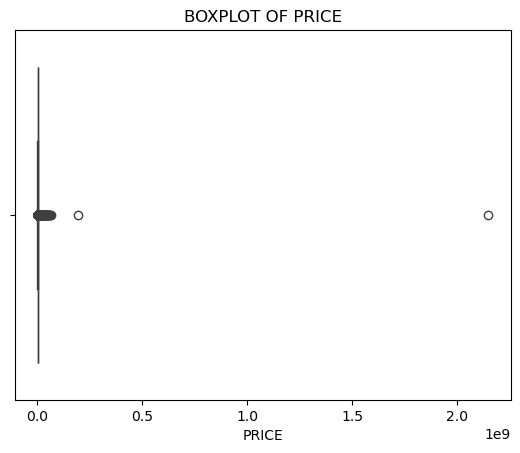

<Figure size 1200x300 with 0 Axes>

In [722]:
plt.title("BOXPLOT OF PRICE")
sns.boxplot(x= nas["PRICE"])
plt.figure(figsize=(12,3))
plt.show()


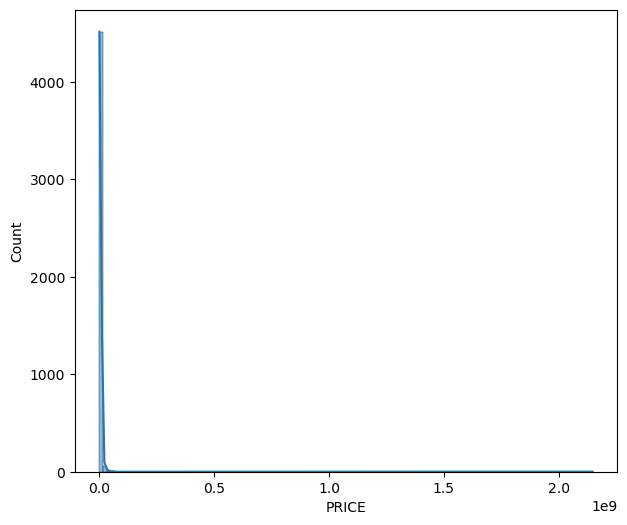

In [723]:
plt.figure(figsize= (7,6))
sns.histplot(nas["PRICE"], kde=True)
plt.show()
           

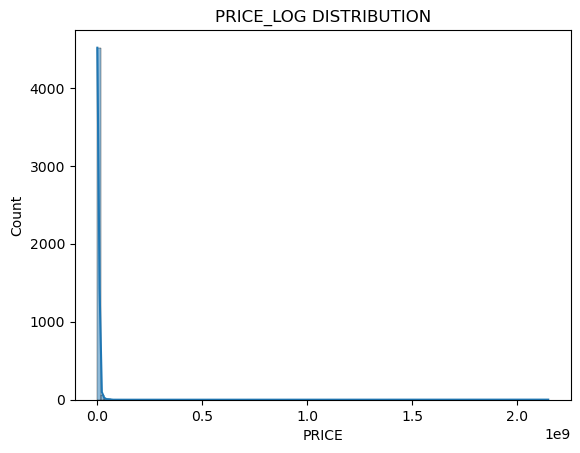

In [724]:
plt.title("PRICE_LOG DISTRIBUTION")
nas["PRICE_LOG"]= np.log1p(nas["PRICE"]) ###LOG TRANSFORMATION OF PRICE.
sns.histplot(nas["PRICE"], kde=True)
plt.show()

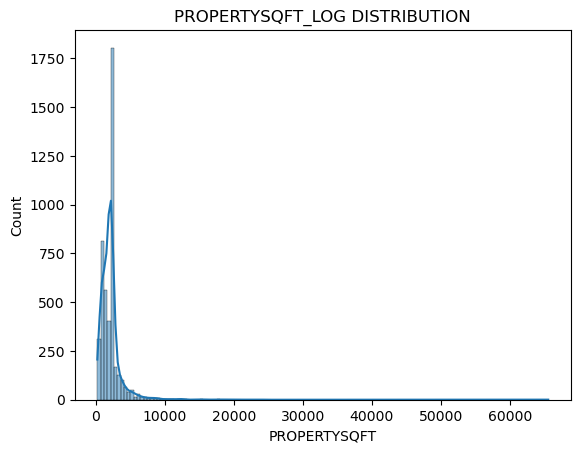

In [725]:
plt.title("PROPERTYSQFT_LOG DISTRIBUTION")
nas["PROPERTYSQFT_LOG"]= np.log1p(nas["PROPERTYSQFT"]) ###LOG TRANSFORMATION OF PRICE.
sns.histplot(nas["PROPERTYSQFT"], kde=True)
plt.show()

In [726]:
nas["PRICE"].max()## Highest Price in the dataset.

2147483647

In [727]:
nas.loc[nas["PRICE"]== nas["PRICE"].max()] #### This input doesnt look like an error regardless of it being an outlier, the information it contains makes clear sense.

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE,PRICE_LOG,PROPERTYSQFT_LOG
304,Brokered by ANNE LOPA REAL ESTATE,House for sale,2147483647,7,6.0,10000.0,6659-6675 Amboy Rd,"New York, NY 10309","6659-6675 Amboy RdNew York, NY 10309",United States,New York,Richmond County,Staten Island,Amboy Road,"6659 Amboy Rd, Staten Island, NY 10309, USA",40.518484,-74.224418,21.487563,9.21044


In [728]:
nas.sort_values(by= "PRICE", ascending=False)[['PRICE','BEDS','BATH','PROPERTYSQFT_LOG','STATE','ADDRESS','PRICE_LOG']].head(10)

,PRICE,BEDS,BATH,PROPERTYSQFT_LOG,STATE,ADDRESS,PRICE_LOG
304,2147483647,7,6.000000,9.210440,"New York, NY 10309",6659-6675 Amboy Rd,21.487563
1,195000000,7,10.000000,9.772581,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,19.088510
69,65000000,3,2.373861,9.629116,"New York, NY 10075",4 E 79th St,17.989898
1075,60000000,8,8.000000,7.689466,"Manhattan, NY 10075",960 5th Ave Unit 12,17.909855
141,56000000,11,10.000000,10.085851,"New York, NY 10019",9 W 54th St,17.840862
99,55000000,8,8.000000,9.392745,"New York, NY 10023",25 Riverside Dr,17.822844
4,55000000,7,2.373861,9.559306,"New York, NY 10065",5 E 64th St,17.822844
626,50000000,6,6.000000,8.790269,"New York, NY 10013",100 Vandam St Apt 20A,17.727534
1453,48000000,5,2.373861,7.689466,"New York, NY 10021",740 Park Ave # 4 & 5B,17.686712
3388,45000000,5,2.373861,7.689466,"New York, NY 10065",4 E 66th St Fl 7,17.622173


i think i got it wrong, through my diggings, that address doesnt look like the kind of address you'd expect the most expensive property.
Again the row 304, 1 and 4 has the largest propertysqft in terms of their prices. The reason why that of row 304 doesnt make sense is
row 1 has 17545 sqft. that is 7545sqft more than row 304 and that of 4 more extra bathrooms.

In [729]:
nas['PRICE'].describe()

count    4.587000e+03
mean     2.381172e+06
std      3.206831e+07
min      2.494000e+03
25%      4.990000e+05
50%      8.250000e+05
75%      1.498500e+06
max      2.147484e+09
Name: PRICE, dtype: float64

In [730]:
nas.columns


Index(['BROKERTITLE', 'TYPE', 'PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT',
       'ADDRESS', 'STATE', 'MAIN_ADDRESS', 'ADMINISTRATIVE_AREA_LEVEL_2',
       'LOCALITY', 'SUBLOCALITY', 'STREET_NAME', 'LONG_NAME',
       'FORMATTED_ADDRESS', 'LATITUDE', 'LONGITUDE', 'PRICE_LOG',
       'PROPERTYSQFT_LOG'],
      dtype='object')

In [731]:
col_to_use=['TYPE','PRICE','PRICE_LOG','BEDS','BATH',"PROPERTYSQFT_LOG","STATE",'LATITUDE', 'LONGITUDE',"LOCALITY"]

In [732]:
nas= nas[col_to_use]

In [733]:
nas.head()

,TYPE,PRICE,PRICE_LOG,BEDS,BATH,PROPERTYSQFT_LOG,STATE,LATITUDE,LONGITUDE,LOCALITY
0,Condo for sale,315000,12.660331,2,2.000000,7.244942,"New York, NY 10022",40.761255,-73.974483,New York
1,Condo for sale,195000000,19.088510,7,10.000000,9.772581,"New York, NY 10019",40.766393,-73.980991,New York
2,House for sale,260000,12.468441,4,2.000000,7.608871,"Staten Island, NY 10312",40.541805,-74.196109,New York
3,Condo for sale,69000,11.141876,3,1.000000,6.100319,"Manhattan, NY 10022",40.761398,-73.974613,New York
4,Townhouse for sale,55000000,17.822844,7,2.373861,9.559306,"New York, NY 10065",40.767224,-73.969856,New York


In [734]:
nas.columns = nas.columns.str.strip()

In [735]:
nas.columns

Index(['TYPE', 'PRICE', 'PRICE_LOG', 'BEDS', 'BATH', 'PROPERTYSQFT_LOG',
       'STATE', 'LATITUDE', 'LONGITUDE', 'LOCALITY'],
      dtype='object')

In [736]:
nas = pd.get_dummies(nas,columns=['TYPE','STATE','LOCALITY'],drop_first=True, dtype=int)

print(nas.head())

       PRICE  PRICE_LOG  BEDS       BATH  PROPERTYSQFT_LOG   LATITUDE  \
0     315000  12.660331     2   2.000000          7.244942  40.761255   
1  195000000  19.088510     7  10.000000          9.772581  40.766393   
2     260000  12.468441     4   2.000000          7.608871  40.541805   
3      69000  11.141876     3   1.000000          6.100319  40.761398   
4   55000000  17.822844     7   2.373861          9.559306  40.767224   

   LONGITUDE  TYPE_Coming Soon  TYPE_Condo for sale  TYPE_Condop for sale  \
0 -73.974483                 0                    1                     0   
1 -73.980991                 0                    1                     0   
2 -74.196109                 0                    0                     0   
3 -73.974613                 0                    1                     0   
4 -73.969856                 0                    0                     0   

   ...  LOCALITY_Brooklyn  LOCALITY_Flatbush  LOCALITY_Kings County  \
0  ...                  0  

In [737]:
print(nas.columns.tolist())
print(nas.shape)##### columns  r]created by the dummies to enhance our machine learning training and testing

['PRICE', 'PRICE_LOG', 'BEDS', 'BATH', 'PROPERTYSQFT_LOG', 'LATITUDE', 'LONGITUDE', 'TYPE_Coming Soon', 'TYPE_Condo for sale', 'TYPE_Condop for sale', 'TYPE_Contingent', 'TYPE_For sale', 'TYPE_Foreclosure', 'TYPE_House for sale', 'TYPE_Land for sale', 'TYPE_Mobile house for sale', 'TYPE_Multi-family home for sale', 'TYPE_Pending', 'TYPE_Townhouse for sale', 'STATE_Astoria, NY 11101', 'STATE_Astoria, NY 11102', 'STATE_Astoria, NY 11103', 'STATE_Astoria, NY 11105', 'STATE_Astoria, NY 11106', 'STATE_Bayside, NY 11360', 'STATE_Bayside, NY 11361', 'STATE_Bayside, NY 11364', 'STATE_Bedford Stuyvesant, NY 11206', 'STATE_Bedford Stuyvesant, NY 11216', 'STATE_Bedford Stuyvesant, NY 11221', 'STATE_Bedford Stuyvesant, NY 11233', 'STATE_Beechhurst, NY 11357', 'STATE_Belle Harbor, NY 11694', 'STATE_Bellerose, NY 11426', 'STATE_Briarwood, NY 11435', 'STATE_Brighton Beach, NY 11235', 'STATE_Bronx Ny, NY 10458', 'STATE_Bronx, NY 10451', 'STATE_Bronx, NY 10452', 'STATE_Bronx, NY 10453', 'STATE_Bronx, N

In [738]:
nas.head(15)

,PRICE,PRICE_LOG,BEDS,BATH,PROPERTYSQFT_LOG,LATITUDE,LONGITUDE,TYPE_Coming Soon,TYPE_Condo for sale,TYPE_Condop for sale,...,LOCALITY_Brooklyn,LOCALITY_Flatbush,LOCALITY_Kings County,LOCALITY_New York,LOCALITY_New York County,LOCALITY_Queens,LOCALITY_Queens County,LOCALITY_Richmond County,LOCALITY_The Bronx,LOCALITY_United States
0,315000,12.660331,2,2.000000,7.244942,40.761255,-73.974483,0,1,0,...,0,0,0,1,0,0,0,0,0,0
1,195000000,19.088510,7,10.000000,9.772581,40.766393,-73.980991,0,1,0,...,0,0,0,1,0,0,0,0,0,0
2,260000,12.468441,4,2.000000,7.608871,40.541805,-74.196109,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,69000,11.141876,3,1.000000,6.100319,40.761398,-73.974613,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,55000000,17.822844,7,2.373861,9.559306,40.767224,-73.969856,0,0,0,...,0,0,0,1,0,0,0,0,0,0
5,690000,13.444448,5,2.000000,8.295299,40.674363,-73.958725,0,0,0,...,0,0,0,1,0,0,0,0,0,0
6,899500,13.709595,2,2.000000,7.689466,40.809448,-73.946777,0,1,0,...,0,0,0,0,1,0,0,0,0,0
7,16800000,16.636890,8,16.000000,10.404293,40.595002,-74.106424,0,0,0,...,0,0,0,1,0,0,0,0,0,0
8,265000,12.487489,1,1.000000,6.621406,40.821586,-73.874089,0,0,0,...,0,0,0,0,0,0,0,0,1,0
9,440000,12.994532,2,1.000000,6.886532,40.615738,-73.969694,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [739]:
nas.columns

Index(['PRICE', 'PRICE_LOG', 'BEDS', 'BATH', 'PROPERTYSQFT_LOG', 'LATITUDE',
       'LONGITUDE', 'TYPE_Coming Soon', 'TYPE_Condo for sale',
       'TYPE_Condop for sale',
       ...
       'LOCALITY_Brooklyn', 'LOCALITY_Flatbush', 'LOCALITY_Kings County',
       'LOCALITY_New York', 'LOCALITY_New York County', 'LOCALITY_Queens',
       'LOCALITY_Queens County', 'LOCALITY_Richmond County',
       'LOCALITY_The Bronx', 'LOCALITY_United States'],
      dtype='object', length=336)

In [740]:
# Select features and target
X = nas.drop(columns=['PRICE_LOG'])
y = nas['PRICE_LOG']#target


In [755]:
X_train_both, X_test_both, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)#### splitting the dataset(training data and testing data )

In [756]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

pipeline= Pipeline([
    ('standard', StandardScaler()),
    ('minmax', MinMaxScaler())
])
X_train_both = pipeline.fit_transform(X_train)
X_test_both = pipeline.transform(X_test)




In [757]:
nas.head()

,PRICE,PRICE_LOG,BEDS,BATH,PROPERTYSQFT_LOG,LATITUDE,LONGITUDE,TYPE_Coming Soon,TYPE_Condo for sale,TYPE_Condop for sale,...,LOCALITY_Brooklyn,LOCALITY_Flatbush,LOCALITY_Kings County,LOCALITY_New York,LOCALITY_New York County,LOCALITY_Queens,LOCALITY_Queens County,LOCALITY_Richmond County,LOCALITY_The Bronx,LOCALITY_United States
0,315000,12.660331,2,2.000000,7.244942,40.761255,-73.974483,0,1,0,...,0,0,0,1,0,0,0,0,0,0
1,195000000,19.088510,7,10.000000,9.772581,40.766393,-73.980991,0,1,0,...,0,0,0,1,0,0,0,0,0,0
2,260000,12.468441,4,2.000000,7.608871,40.541805,-74.196109,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,69000,11.141876,3,1.000000,6.100319,40.761398,-73.974613,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,55000000,17.822844,7,2.373861,9.559306,40.767224,-73.969856,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [758]:
X_train_both_nas= pd.DataFrame(X_train_both,columns= X_train.columns, index=X_train.index)
X_train_both_nas.head()

,PRICE,BEDS,BATH,PROPERTYSQFT_LOG,LATITUDE,LONGITUDE,TYPE_Coming Soon,TYPE_Condo for sale,TYPE_Condop for sale,TYPE_Contingent,...,LOCALITY_Brooklyn,LOCALITY_Flatbush,LOCALITY_Kings County,LOCALITY_New York,LOCALITY_New York County,LOCALITY_Queens,LOCALITY_Queens County,LOCALITY_Richmond County,LOCALITY_The Bronx,LOCALITY_United States
343,0.000323,0.040816,0.040000,0.319713,0.279942,0.167001,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2568,0.001299,0.061224,0.040000,0.390627,0.721105,0.510358,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2533,0.000919,0.081633,0.047477,0.456209,0.462653,0.619931,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2599,0.000360,0.000000,0.020000,0.210801,0.707638,0.501744,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4653,0.000113,0.040816,0.020000,0.390627,0.586555,0.659011,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [777]:
ridge = Ridge(alpha=0.01)

ridge.fit(X_train_both, y_train)

ridge_pred = ridge.predict(X_test_both)

In [778]:
ridge_r2 = r2_score(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))

print(f"Ridge R²:", ridge_r2)
print(f"Ridge RMSE:", ridge_rmse)

Ridge R²: 0.7121869325474413
Ridge RMSE: 0.5582925218644769


In [779]:
lasso = Lasso(alpha=0.001)

lasso.fit(X_train_both, y_train)

lasso_pred = lasso.predict(X_test_both)

In [780]:
lasso_r2 = r2_score(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))

print(f"Lasso R²:", lasso_r2)
print(f"Lasso RMSE:", lasso_rmse)

Lasso R²: 0.6359147921647403
Lasso RMSE: 0.6279254332630014


In [781]:
from sklearn.linear_model import RidgeCV
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_both, y_train)

print(ridge_cv.alphas)
print(ridge_cv.score(X_test_both, y_test))

[0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
0.6856619722074645


###CV in here means cross validation and that divides your dataset into 5 folds ie  if cv=5,
acting like a loop with the available alphas(lambda) that is it trains the dataset 4x and test it once in each fold and tells us the 
what the perfect lambda for the regression model should be rather than just splitting your data into two and juts guessing yo
    a better r2 and not thinking about how the alpha penalizes the coeffiecients.
   CV is all about reliability and computation, the higher the CV, the higher the reliability of the r2.

In [782]:
from sklearn.linear_model import LassoCV
lasso_cv= LassoCV(cv=5, random_state=42)
lasso_cv.fit(X_train_both, y_train)

print(lasso_cv.alpha_)
print(lasso_cv.score(X_test_both, y_test))

0.0004069149935967446
0.6718918211880538


In [783]:
model = ElasticNet(
    alpha=0.001,
    l1_ratio=0.001,
    random_state=42
)
model.fit(X_train_both, y_train)
y_pred = model.predict(X_test_both)

In [784]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error:", mse)
print(f"R² Score:", r2)

Mean Squared Error: 0.36582291866233685
R² Score: 0.6622014374422224
